In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


# Exploratory Data Analysis :

In [4]:
query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [5]:
df.shape

(51295, 23)

In [6]:
df.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'country',
 'state',
 'city',
 'region',
 'postal_code',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'product_name',
 'category',
 'sub_category',
 'customer_name',
 'segment',
 'returned',
 'market']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51295 entries, 0 to 51294
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       51295 non-null  object 
 1   customer_id    51295 non-null  object 
 2   product_id     51295 non-null  object 
 3   order_date     51295 non-null  object 
 4   ship_date      51295 non-null  object 
 5   ship_mode      51295 non-null  object 
 6   country        51295 non-null  object 
 7   state          51295 non-null  object 
 8   city           51295 non-null  object 
 9   region         51295 non-null  object 
 10  postal_code    51295 non-null  object 
 11  sales          51295 non-null  float64
 12  quantity       51295 non-null  int64  
 13  discount       51295 non-null  float64
 14  profit         51295 non-null  float64
 15  shipping_cost  51295 non-null  float64
 16  product_name   51295 non-null  object 
 17  category       51295 non-null  object 
 18  sub_ca

In [8]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [9]:
df.isnull().sum()

order_id             0
customer_id          0
product_id           0
order_date           0
ship_date            0
ship_mode            0
country              0
state                0
city                 0
region               0
postal_code          0
sales                0
quantity             0
discount             0
profit               0
shipping_cost        0
product_name         0
category             0
sub_category         0
customer_name        0
segment              0
returned             0
market           48240
dtype: int64

In [10]:
((df.isnull().sum()/len(df)) * 100).round(2)

order_id          0.00
customer_id       0.00
product_id        0.00
order_date        0.00
ship_date         0.00
ship_mode         0.00
country           0.00
state             0.00
city              0.00
region            0.00
postal_code       0.00
sales             0.00
quantity          0.00
discount          0.00
profit            0.00
shipping_cost     0.00
product_name      0.00
category          0.00
sub_category      0.00
customer_name     0.00
segment           0.00
returned          0.00
market           94.04
dtype: float64

* As we can see here we have approx 94% of data is missing in `market` Column,
hence this is of no use for us so we are dropping it.

In [12]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

 ### Distribution of numeric variables :

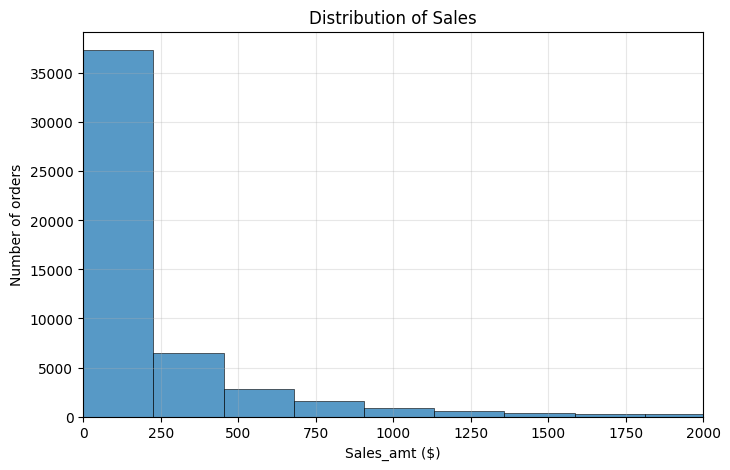

In [16]:
# Distribution of Sales :

plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=100)
plt.xlim(0, 2000)

plt.title("Distribution of Sales")

plt.xlabel('Sales_amt ($)')
plt.ylabel('Number of orders')

plt.grid(alpha = 0.3)

plt.show()

* The distribution of sales is highly right-skewed. Most orders have low sales values, while only a small number of orders generate very high sales. This indicates that the business receives many small purchases and only a few large transactions.
* This suggests that the company's revenue is driven by a large volume of small orders rather than a few large transactions.

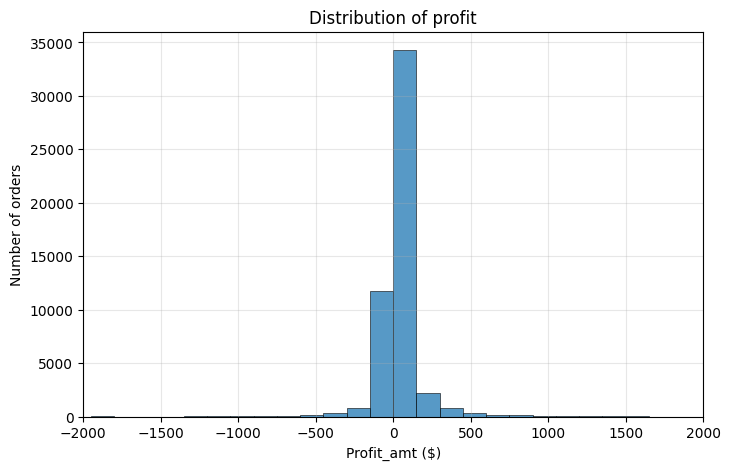

In [17]:
# Distribution of Profit :- 

plt.figure(figsize=(8,5))
sns.histplot(df['profit'], bins=100)

plt.xlim(-2000, 2000)

plt.xlabel('Profit_amt ($)')
plt.ylabel('Number of orders')

plt.grid(alpha = 0.3)

plt.title("Distribution of profit")
plt.show()

As we can observe from the profit distribution chart that data is mostly in the center, which means mostly the profit is on positive side and rest is on the negative side.

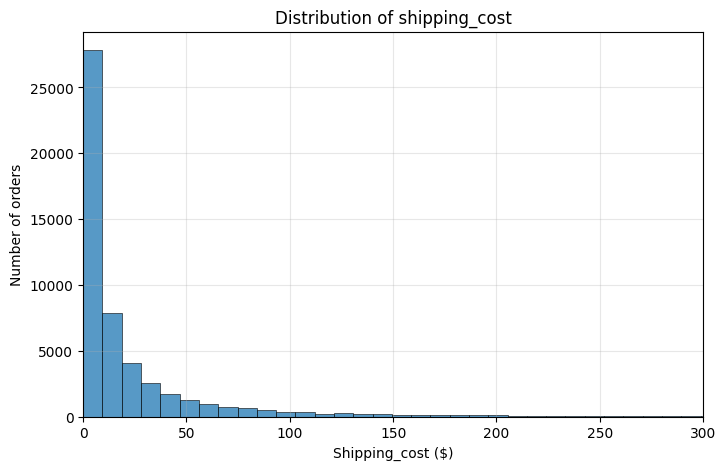

In [21]:
## Distribution of Shipping Cost :- 

plt.figure(figsize=(8,5))
sns.histplot(df['shipping_cost'], bins=100)

plt.xlim(0, 300)
plt.xlabel('Shipping_cost ($)')
plt.ylabel('Number of orders')

plt.grid(alpha = 0.3)

plt.title("Distribution of shipping_cost")
plt.show()

* The data is right-skewed, showing that most shipping costs are low (under $100), with a sharp drop-off as prices increase.

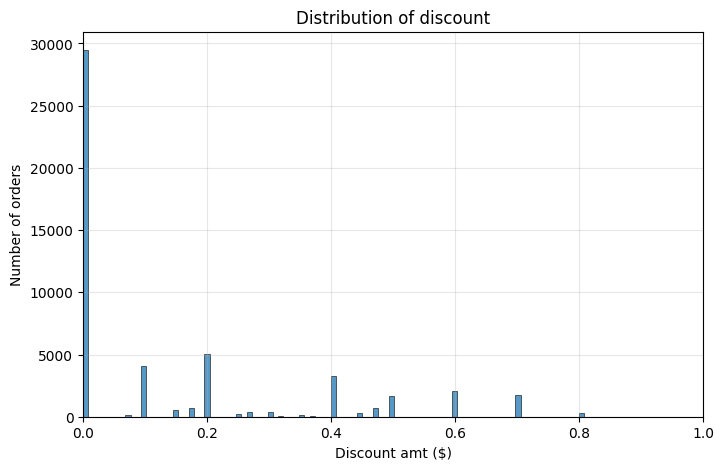

In [79]:
## Distribution of Discount :- 

plt.figure(figsize = (8,5))
sns.histplot(df['discount'], bins = 100)

plt.xlim(0,1)
plt.xlabel('Discount amt ($)')
plt.ylabel('Number of orders')

plt.grid(alpha = 0.3)

plt.title('Distribution of discount')
plt.show()

* The distribution shows that most orders are sold without any discount, indicating that the business primarily sells products at full price.

### Relationships between the attributes :

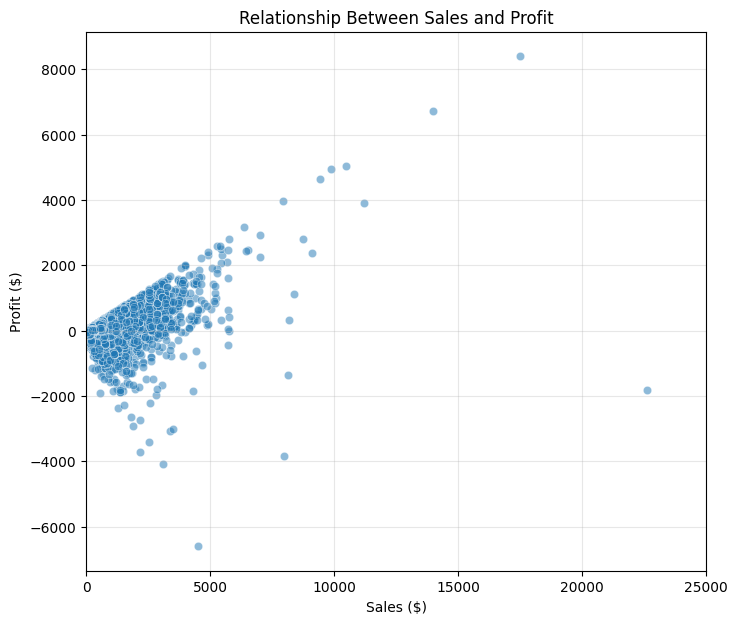

In [24]:
## Profit vs Sales Relationships :

plt.figure(figsize=(8,7))

sns.scatterplot(x=df['sales'], y=df['profit'], alpha=0.5)

plt.xlim(0,25000)
plt.title('Relationship Between Sales and Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')

plt.grid(alpha = 0.3)

plt.show()

* As we can observe from above Scatter plot that The sales increases profit is also increases but we can also see that
The scatter plot reveals that some transactions generate large losses despite relatively high sales values.

Text(0.5, 1.0, 'Relation between Sales, Profit and Discount')

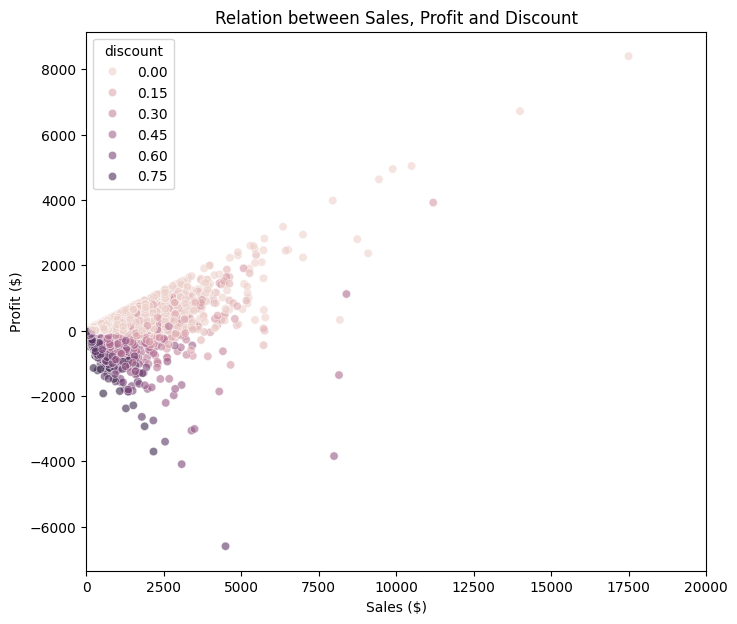

In [46]:
## Relation between sales and profit affected by discount

plt.figure(figsize = (8,7))

sns.scatterplot(x=df['sales'], y=df['profit'],
                hue=df['discount'], alpha=0.6)
plt.xlim(0, 20000)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.title ('Relation between Sales, Profit and Discount')

* The scatter plot shows that higher discounts are often associated with lower or negative profits, even when sales are relatively high, suggesting that excessive discounting may reduce overall profitability.

### Discount vs profit relationship 

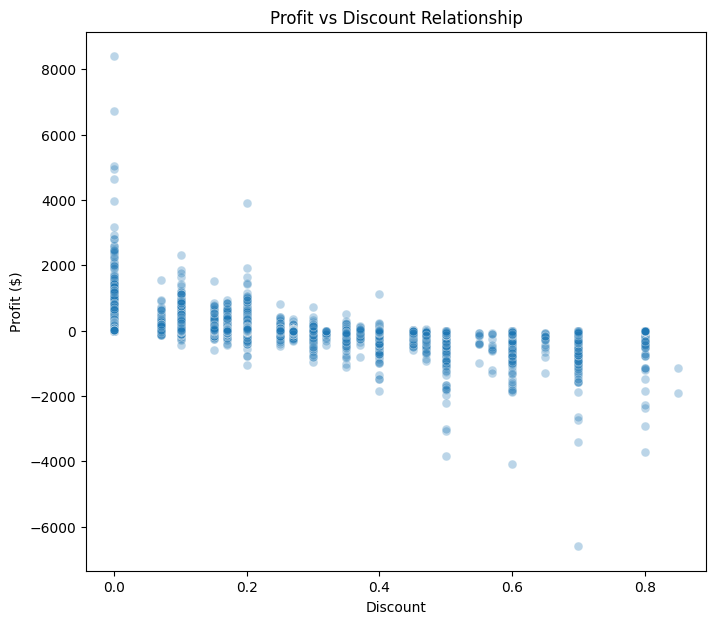

In [63]:
plt.figure(figsize=(8,7))

sns.scatterplot(
    x='discount',
    y='profit',
    data=df,
    alpha=0.3,
    s=40
)

plt.title('Profit vs Discount Relationship')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()

* The scatter plot shows a negative relationship between discount and profit. As the discount level increases, profitability tends to decrease. Orders with higher discounts frequently result in negative profits, indicating that excessive discounting may significantly reduce the company's profitability.

### Discount vs Sales Relationship

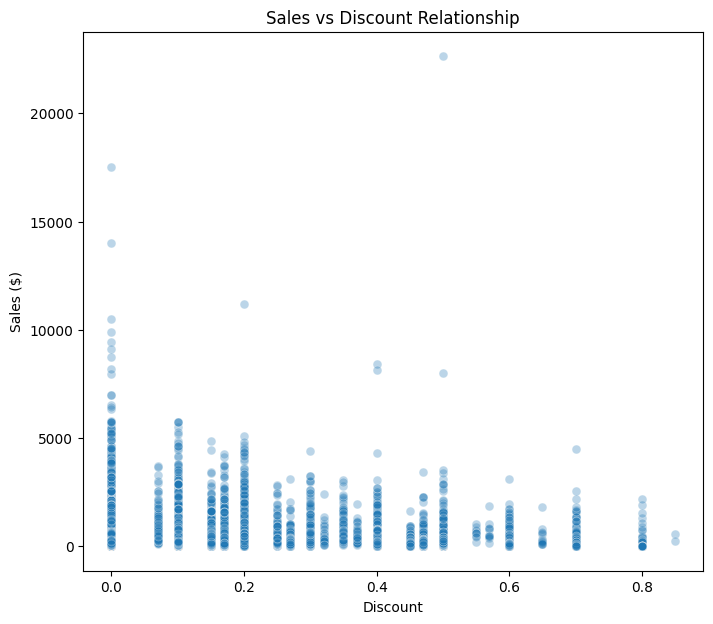

In [62]:
plt.figure(figsize=(8,7))

sns.scatterplot(
    x='discount',
    y='sales',
    data=df,
    alpha=0.3,
    s=40
)

plt.title('Sales vs Discount Relationship')
plt.xlabel('Discount')
plt.ylabel('Sales ($)')
plt.show()

### Correlation Analysis :

In [131]:
df[['sales','profit','discount','quantity','shipping_cost']].corr()

,sales,profit,discount,quantity,shipping_cost
sales,1.000000,0.484921,-0.086781,0.313580,0.767937
profit,0.484921,1.000000,-0.316513,0.104365,0.354410
discount,-0.086781,-0.316513,1.000000,-0.019871,-0.079192
quantity,0.313580,0.104365,-0.019871,1.000000,0.272416
shipping_cost,0.767937,0.354410,-0.079192,0.272416,1.000000


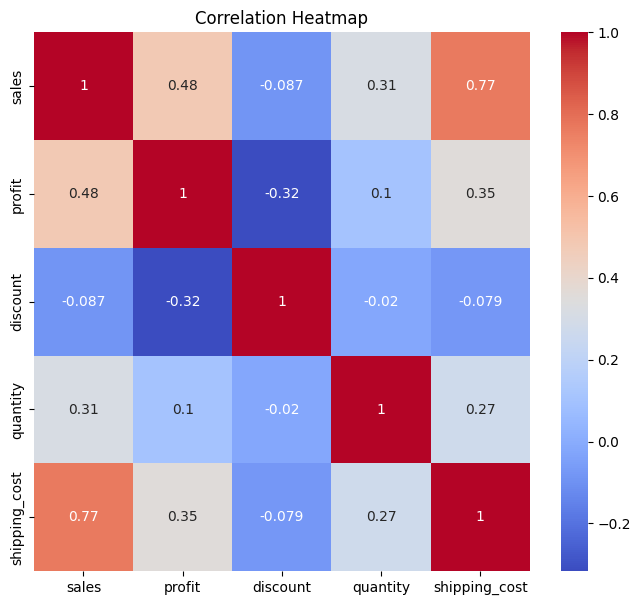

In [38]:
corr_matrix = df[['sales','profit','discount','quantity','shipping_cost']].corr() 

plt.figure(figsize = (8,7))
sns.heatmap(corr_matrix, annot = True, cmap ='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Quick Interpretation of Correlations

| Pair of variables          | Correlation | Simple meaning                                              | Strength       |
|----------------------------|-------------|-------------------------------------------------------------|----------------|
| sales ↔ shipping_cost      | **+0.77**   | Very strong! High sales usually come with high shipping cost | **Very strong** |
| sales ↔ profit             | **+0.48**   | Moderate. More sales tend to bring more profit              | Moderate       |
| profit ↔ discount          | **-0.32**   | Moderate negative. Bigger discounts usually hurt profit     | Moderate       |
| sales ↔ discount           | **-0.087**  | Almost nothing. Discounts don’t really affect sales much    | Very weak      |
| discount ↔ quantity        | **-0.02**   | Basically zero connection                                   | None           |
| profit ↔ quantity          | **+0.10**   | Very weak positive. Selling more units helps profit only a bit | Very weak   |
| quantity ↔ shipping_cost   | **+0.27**   | Mild positive. More items → somewhat higher shipping cost   | Weak-moderate  |
| sales ↔ quantity           | **+0.31**   | Moderate. More sales usually mean more units sold           | Moderate       |

**Most important takeaways:**
- **Sales and shipping_cost move together strongly** (+0.77) → higher sales almost always mean higher shipping costs
- **Discounts clearly reduce profit** (-0.32), but they don't meaningfully increase sales (-0.09)
- Quantity sold has only weak/moderate links to most other variables

The strongest story in this data:  
**More sales → much higher shipping costs**  
**Bigger discounts → lower profits**

### Key Correlations – Summary

- **Very strong positive**: sales ↔ shipping_cost (+0.77)  
- **Moderate positive**: sales ↔ profit (+0.48), sales ↔ quantity (+0.31)  
- **Moderate negative**: profit ↔ discount (-0.32)  
- **Weak / almost none**: discount with almost everything else, profit ↔ quantity (+0.10)

**Main business messages:**
- High sales drive up shipping costs a lot
- Discounts hurt profit noticeably, but don't really boost sales

---
---

# **Summary** : Exploratory Data Analysis (EDA)

### 1. Data Cleaning & Preparation

* Converted `order_date` and `ship_date` into datetime format so that time-based analysis can be done correctly.
* The `market` column had about **94% missing values**, so it was removed from the dataset.
* Other important columns such as **sales, profit, and shipping_cost** had no missing values and were ready for analysis.

### 2. Understanding the Data Distribution

* **Sales and Shipping Cost are right-skewed**, meaning most orders have small values, while only a few orders have very high values.
* **Profit values are mostly close to zero**, but there are some orders with very high profits and some with large losses.
* Most orders are placed **without any discount**, and when discounts are given they usually appear at fixed levels like **20% or 50%**.

### 3. Key Relationships & Insights

* **Sales and Profit generally increase together**, but high sales do not always mean high profit.
* Some orders with large sales still generate **negative profit**.
* Higher discounts are strongly linked with **lower profitability**, and many orders with discounts above **20–30% result in losses**.
